In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow opencv-python matplotlib scikit-learn pillow -q

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from google.colab import files
from google.colab.patches import cv2_imshow
import os
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [21]:
data_path = '/content/drive/My Drive/bottle_dataset'  # CHANGE THIS

pass_path = os.path.join(data_path, 'PASS')
fail_path = os.path.join(data_path, 'FAIL')

print(f"📁 Pass folder exists: {os.path.exists(pass_path)}")
print(f"📁 Fail folder exists: {os.path.exists(fail_path)}")
if os.path.exists(pass_path):
    print(f"📸 Pass images: {len(os.listdir(pass_path))}")
if os.path.exists(fail_path):
    print(f"📸 Fail images: {len(os.listdir(fail_path))}")

📁 Pass folder exists: True
📁 Fail folder exists: True
📸 Pass images: 327
📸 Fail images: 299


In [22]:
def prepare_dataset(pass_path, fail_path, target_size=(224, 224)):
    images = []
    labels = []

    # Load pass images (label = 1)
    for img_name in os.listdir(pass_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(pass_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                images.append(img)
                labels.append(1)
                 # Load fail images (label = 0)
    for img_name in os.listdir(fail_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(fail_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                images.append(img)
                labels.append(0)

    images = np.array(images, dtype='float32') / 255.0
    labels = np.array(labels)
    # Split: 70% train, 15% val, 15% test
    X_temp, X_test, y_temp, y_test = train_test_split(
        images, labels, test_size=0.15, random_state=42, stratify=labels
    )

    val_size = 0.176
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=42, stratify=y_temp
    )

    print(f"📊 Training: {len(X_train)} images")
    print(f"📊 Validation: {len(X_val)} images")
    print(f"📊 Test: {len(X_test)} images")

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = prepare_dataset(pass_path, fail_path)

📊 Training: 336 images
📊 Validation: 72 images
📊 Test: 72 images


In [23]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)

In [24]:
def build_model(input_shape=(224, 224, 3)):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_model()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model built successfully!")

✅ Model built successfully!


In [25]:
# Cell 7: Train the model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

print("🚀 Training started...")
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Training completed!")

🚀 Training started...
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.6905 - loss: 0.5935 - val_accuracy: 0.8333 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 524ms/step - accuracy: 0.8571 - loss: 0.3680 - val_accuracy: 0.9306 - val_loss: 0.1892 - learning_rate: 0.0010
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step - accuracy: 0.8988 - loss: 0.2664 - val_accuracy: 0.9306 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 319ms/step - accuracy: 0.9226 - loss: 0.1958 - val_accuracy: 0.9444 - val_loss: 0.1133 - learning_rate: 0.0010
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step - accuracy: 0.9405 - loss: 0.1893 - val_accuracy: 0.9583 - val_loss: 0.0719 - learning_rate: 0.0010
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - accuracy: 0.9226 - loss: 0.1813 - val_accuracy: 0.9444 - val_loss: 0.0913 - learning_rate: 0.0010
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 323ms/step - accuracy: 0.94

In [26]:
# Cell 8: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n🎯 Test Accuracy: {test_acc:.3f} ({test_acc*100:.1f}%)")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9722 - loss: 0.1552

🎯 Test Accuracy: 0.972 (97.2%)


In [27]:
# Cell 9: Save model
model.save('/content/bottle_orientation_model.h5')
print("💾 Model saved successfully!")

💾 Model saved successfully!


In [28]:
# Cell 10: Prediction function
def predict_bottle_orientation(image_path_or_array, model):
    """Predict if bottle orientation is pass or fail"""
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array)
        if img is None:
            return "❌ Error loading image", 0
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = image_path_or_array.copy()

    img = cv2.resize(img, (224, 224))
    img_array = np.array(img, dtype='float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    confidence = prediction[0][0]

    if confidence > 0.5:
        result = "✅ PASS - Bottle is UPRIGHT"
        confidence_percent = confidence * 100
    else:
        result = "❌ FAIL - Bottle is TILTED or UPSIDE DOWN"
        confidence_percent = (1 - confidence) * 100

    return result, confidence_percent


In [29]:
# OPTION 1: WEBCAM DETECTION (FIXED VERSION)
# ==============================================

# Cell 11: Webcam detection using JavaScript (Works in Colab)
from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image

# JavaScript for webcam capture
def init_webcam():
    """Initialize webcam and return capture function"""

    js_code = '''
    <div id="webcam-container">
        <video id="webcam" width="400" height="400" autoplay playsinline></video>
        <div style="margin-top: 10px;">
            <button id="capture-btn" style="padding: 10px 20px; font-size: 16px; background-color: #4CAF50; color: white; border: none; border-radius: 5px; cursor: pointer;">
                📸 Capture & Analyze
            </button>
            <button id="restart-btn" style="padding: 10px 20px; font-size: 16px; background-color: #f44336; color: white; border: none; border-radius: 5px; cursor: pointer; margin-left: 10px;">
                🔄 Restart Camera
            </button>
        </div>
    </div>
    <div id="result" style="margin-top: 20px; padding: 15px; font-size: 18px; font-weight: bold;"></div>
    <canvas id="canvas" style="display: none;"></canvas>

    <script>
    var video = document.getElementById('webcam');
    var canvas = document.getElementById('canvas');
    var resultDiv = document.getElementById('result');

    async function startCamera() {
        try {
            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();
            return true;
        } catch(err) {
            resultDiv.innerHTML = '❌ Error accessing camera: ' + err.message;
            return false;
        }
    }

    function captureImage() {
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        return canvas.toDataURL('image/jpeg', 0.8);
    }

    document.getElementById('capture-btn').onclick = function() {
        var imageData = captureImage();
        var result = google.colab.kernel.invokeFunction('notebook.process_image', [imageData], {});
        resultDiv.innerHTML = '🔍 Analyzing...';
    };

    document.getElementById('restart-btn').onclick = function() {
        if (video.srcObject) {
            video.srcObject.getTracks().forEach(track => track.stop());
        }
        startCamera();
    };

    startCamera();
    </script>
    '''

    display(HTML(js_code))

# Register callback for image processing
from google.colab import output
import base64
import io

def process_image_from_js(image_data):
    """Process image received from JavaScript"""
    # Decode base64 image
    image_data = image_data.split(',')[1]
    image_bytes = base64.b64decode(image_data)
    image = PIL.Image.open(io.BytesIO(image_bytes))
    image = np.array(image)

    # Predict
    result, confidence = predict_bottle_orientation(image, model)

    # Display result
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Captured Image\n{result}\nConfidence: {confidence:.1f}%")
    plt.show()

    print(f"\n{'='*50}")
    print(f"🔍 RESULT: {result}")
    print(f"📊 Confidence: {confidence:.1f}%")
    print(f"{'='*50}\n")

    return "Processed"

# Register the function
output.register_callback('notebook.process_image', process_image_from_js)


🎥 WEBCAM DETECTION MODE (with Stop button)
✅ Click 'Allow' for camera permission
📸 Position the bottle
🔘 Click 'Capture & Analyze' to check orientation
⏹️ Click 'Stop Webcam' when done
🔄 Click 'Restart Camera' if needed

🚀 Starting webcam...



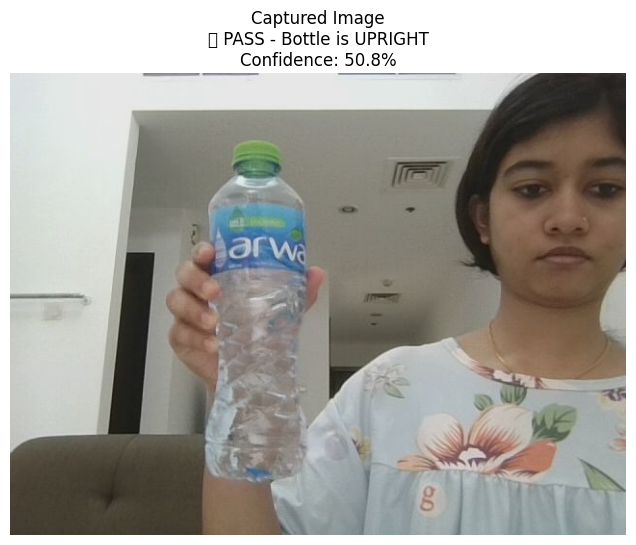


🔍 RESULT: ✅ PASS - Bottle is UPRIGHT
📊 Confidence: 50.8%



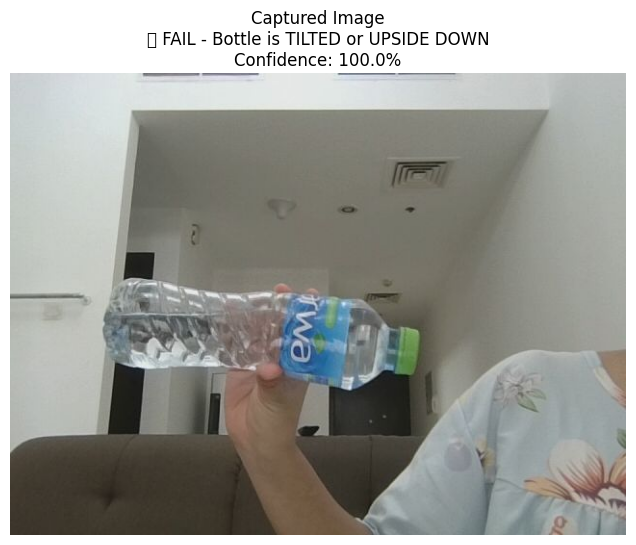


🔍 RESULT: ❌ FAIL - Bottle is TILTED or UPSIDE DOWN
📊 Confidence: 100.0%



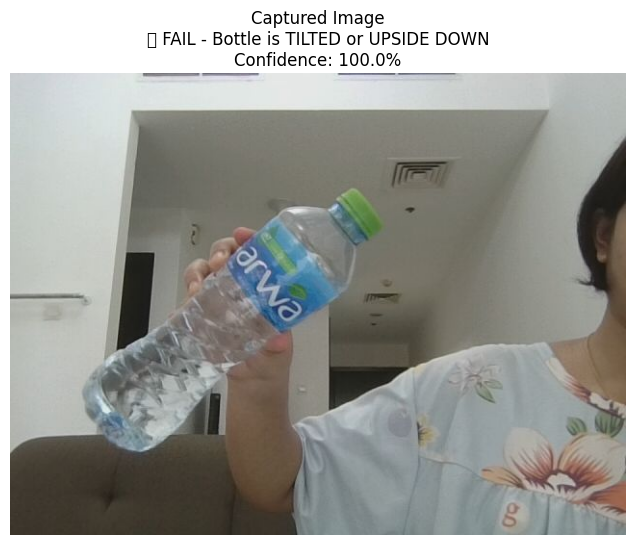


🔍 RESULT: ❌ FAIL - Bottle is TILTED or UPSIDE DOWN
📊 Confidence: 100.0%



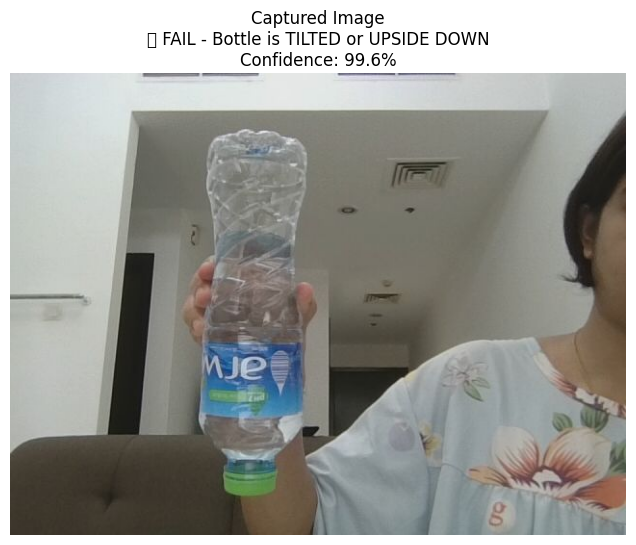


🔍 RESULT: ❌ FAIL - Bottle is TILTED or UPSIDE DOWN
📊 Confidence: 99.6%



In [36]:
# Cell 12: Webcam with Stop button
from IPython.display import display, Javascript, HTML
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image

def init_webcam_with_stop():
    """Initialize webcam with stop button"""

    js_code = '''
    <div id="webcam-container">
        <video id="webcam" width="400" height="400" autoplay playsinline></video>
        <div style="margin-top: 10px;">
            <button id="capture-btn" style="padding: 10px 20px; font-size: 16px; background-color: #4CAF50; color: white; border: none; border-radius: 5px; cursor: pointer;">
                📸 Capture & Analyze
            </button>
            <button id="restart-btn" style="padding: 10px 20px; font-size: 16px; background-color: #ff9800; color: white; border: none; border-radius: 5px; cursor: pointer; margin-left: 10px;">
                🔄 Restart Camera
            </button>
            <button id="stop-btn" style="padding: 10px 20px; font-size: 16px; background-color: #f44336; color: white; border: none; border-radius: 5px; cursor: pointer; margin-left: 10px;">
                ⏹️ Stop Webcam
            </button>
        </div>
    </div>
    <div id="result" style="margin-top: 20px; padding: 15px; font-size: 18px; font-weight: bold;"></div>
    <canvas id="canvas" style="display: none;"></canvas>

    <script>
    var video = document.getElementById('webcam');
    var canvas = document.getElementById('canvas');
    var resultDiv = document.getElementById('result');
    var currentStream = null;

    async function startCamera() {
        try {
            if (currentStream) {
                currentStream.getTracks().forEach(track => track.stop());
            }
            currentStream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = currentStream;
            await video.play();
            return true;
        } catch(err) {
            resultDiv.innerHTML = '❌ Error accessing camera: ' + err.message;
            return false;
        }
    }

    function stopCamera() {
        if (currentStream) {
            currentStream.getTracks().forEach(track => {
                track.stop();
                console.log('Stopped track:', track.kind);
            });
            currentStream = null;
            video.srcObject = null;
        }
        if (video) {
            video.pause();
        }
        resultDiv.innerHTML = '✅ Webcam stopped. You can close this cell now.';
    }

    function captureImage() {
        if (!currentStream) {
            resultDiv.innerHTML = '❌ Camera not running. Click Restart Camera first.';
            return null;
        }
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        return canvas.toDataURL('image/jpeg', 0.8);
    }

    document.getElementById('capture-btn').onclick = function() {
        var imageData = captureImage();
        if (imageData) {
            resultDiv.innerHTML = '🔍 Analyzing...';
            google.colab.kernel.invokeFunction('notebook.process_image', [imageData], {});
        }
    };

    document.getElementById('restart-btn').onclick = function() {
        stopCamera();
        startCamera();
    };

    document.getElementById('stop-btn').onclick = function() {
        stopCamera();
        setTimeout(() => {
            const container = document.getElementById('webcam-container');
            if (container) {
                container.style.opacity = '0.5';
            }
        }, 100);
    };

    startCamera();
    </script>
    '''

    display(HTML(js_code))

# Register callback for image processing
from google.colab import output
import base64
import io

def process_image_from_js(image_data):
    """Process image received from JavaScript"""
    image_data = image_data.split(',')[1]
    image_bytes = base64.b64decode(image_data)
    image = PIL.Image.open(io.BytesIO(image_bytes))
    image = np.array(image)

    result, confidence = predict_bottle_orientation(image, model)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Captured Image\n{result}\nConfidence: {confidence:.1f}%")
    plt.show()

    print(f"\n{'='*50}")
    print(f"🔍 RESULT: {result}")
    print(f"📊 Confidence: {confidence:.1f}%")
    print(f"{'='*50}\n")

    return "Processed"

output.register_callback('notebook.process_image', process_image_from_js)

# Start webcam with stop button
print("\n" + "="*60)
print("🎥 WEBCAM DETECTION MODE (with Stop button)")
print("="*60)
print("✅ Click 'Allow' for camera permission")
print("📸 Position the bottle")
print("🔘 Click 'Capture & Analyze' to check orientation")
print("⏹️ Click 'Stop Webcam' when done")
print("🔄 Click 'Restart Camera' if needed")
print("\n🚀 Starting webcam...\n")

init_webcam_with_stop()


📤 IMAGE UPLOAD MODE
Upload any bottle image to check orientation
Run this cell again to test another image



Saving Gemini_Generated_Image_5kkztz5kkztz5kkz.png to Gemini_Generated_Image_5kkztz5kkztz5kkz.png


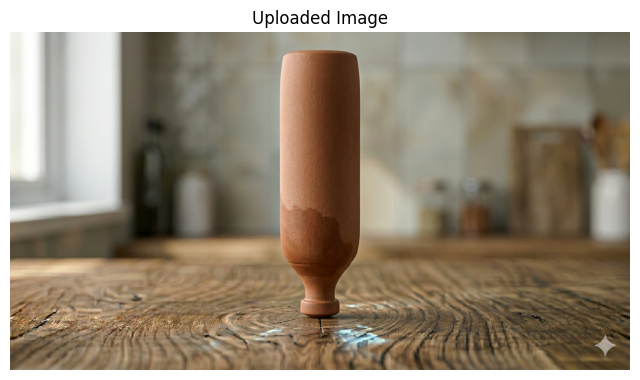


🔍 RESULT: ❌ FAIL - Bottle is TILTED or UPSIDE DOWN
📊 Confidence: 99.1%
🎯 Very confident prediction



In [33]:
# OPTION 2: UPLOAD IMAGE ANY TIME (REPLACEABLE)
# ==============================================

# Cell 13: Upload and test any image (can run multiple times)
def upload_and_test():
    """Upload an image and predict - can run this cell multiple times"""
    print("\n" + "="*60)
    print("📤 IMAGE UPLOAD MODE")
    print("="*60)
    print("Upload any bottle image to check orientation")
    print("Run this cell again to test another image\n")

    uploaded = files.upload()

    for filename in uploaded.keys():
        # Read and display image
        img = cv2.imread(filename)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title("Uploaded Image")
        plt.show()

        # Predict
        result, confidence = predict_bottle_orientation(filename, model)

        print(f"\n{'='*50}")
        print(f"🔍 RESULT: {result}")
        print(f"📊 Confidence: {confidence:.1f}%")

        if confidence > 80:
            print("🎯 Very confident prediction")
        elif confidence > 60:
            print("⚠️ Moderately confident - check image clarity")
        else:
            print("❓ Low confidence - image might be unclear or not a bottle")

        print(f"{'='*50}\n")

        # Clean up uploaded file
        os.remove(filename)

# Run this cell to upload and test an image
# You can run this cell multiple times to test different images
upload_and_test()



🔍 TESTING ON UNSEEN IMAGES


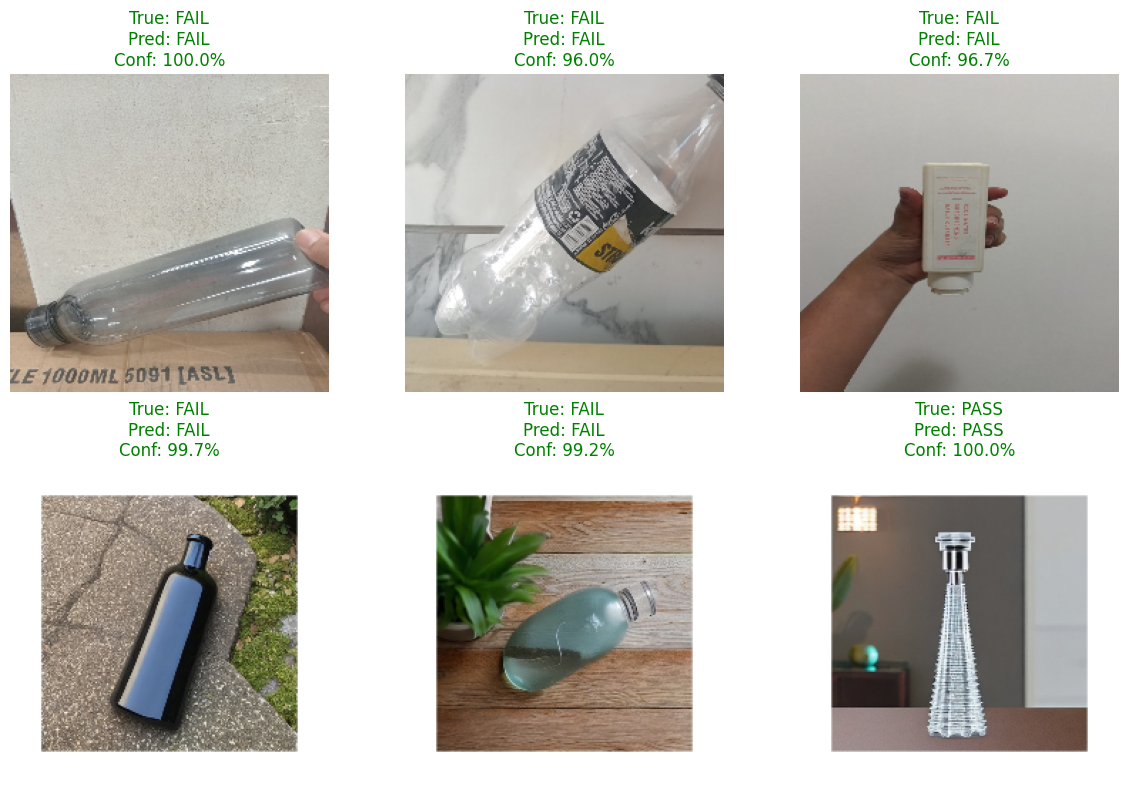


📊 Overall Test Set Accuracy: 97.2%


In [34]:
# OPTION 3: BULK TEST ON TEST SET
# ==============================================

# Cell 14: Test on multiple unseen images from test set
def test_multiple_images():
    """Test model on random images from test set"""
    print("\n" + "="*60)
    print("🔍 TESTING ON UNSEEN IMAGES")
    print("="*60)

    n_images = min(6, len(X_test))
    indices = np.random.choice(len(X_test), n_images, replace=False)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()

    for i, idx in enumerate(indices):
        img = X_test[idx]
        true_label = y_test[idx]

        # Predict
        pred = model.predict(img.reshape(1, 224, 224, 3), verbose=0)[0][0]
        pred_label = "PASS" if pred > 0.5 else "FAIL"
        true_label_text = "PASS" if true_label == 1 else "FAIL"
        confidence = pred if pred > 0.5 else 1-pred

        # Set color based on correct/incorrect
        is_correct = (pred > 0.5) == (true_label == 1)
        color = 'green' if is_correct else 'red'

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label_text}\nPred: {pred_label}\nConf: {confidence:.1%}",
                         color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate overall accuracy
    predictions = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    accuracy = np.mean(predictions == y_test)
    print(f"\n📊 Overall Test Set Accuracy: {accuracy:.1%}")

# Run this to see test results
test_multiple_images()


In [35]:
# Cell 15: Quick reference
print("\n" + "="*60)
print("📚 QUICK REFERENCE GUIDE")
print("="*60)
print("\n🔹 TO USE WEBCAM:")
print("   → Run Cell 12")
print("   → Allow camera permission")
print("   → Click 'Capture & Analyze'")
print("\n🔹 TO TEST SINGLE IMAGE:")
print("   → Run Cell 13")
print("   → Upload image")
print("   → Run Cell 13 again for another image")
print("\n🔹 TO TEST BATCH OF IMAGES:")
print("   → Run Cell 14")
print("\n✅ Model accuracy target: 90%+")
print("✅ If accuracy is low, add more training images")
print("="*60)


📚 QUICK REFERENCE GUIDE

🔹 TO USE WEBCAM:
   → Run Cell 12
   → Allow camera permission
   → Click 'Capture & Analyze'

🔹 TO TEST SINGLE IMAGE:
   → Run Cell 13
   → Upload image
   → Run Cell 13 again for another image

🔹 TO TEST BATCH OF IMAGES:
   → Run Cell 14

✅ Model accuracy target: 90%+
✅ If accuracy is low, add more training images
